In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import chi2
from matplotlib.ticker import AutoLocator
from scipy.stats import anderson

import matplotlib as mpl

mpl.rcParams.update({"text.usetex": True, "font.size": 16,})

In [5]:
d = 4*64*64 # latent dimension of SD1.5
samples = 100
alphas = [1e-4, 1e-3]  # base alpha values
ps = [i/10 for i in range(10)]  # probabilities for alpha doubling

In [6]:
def simulate_noise(alpha, p, d, k_max, ood_percentile=0.99):
    # Initial population
    z0 = np.random.randn(samples, d)
    z_min = np.min(z0, axis=0)
    z_max = np.max(z0, axis=0)

    # Scale factor
    R = np.mean(z_max - z_min)

    # Storage
    zs = np.zeros((k_max + 1, samples, d))
    zs[0] = z0
    alpha_current = np.full(samples, alpha)

    for k in range(1, k_max + 1):
        # Crossover operator
        indices = np.random.permutation(samples)
        half_d = d // 2
        for i in range(0, samples - 1, 2):
            zs[k - 1, indices[i], :half_d], zs[k - 1, indices[i + 1], :half_d] = \
                zs[k - 1, indices[i + 1], :half_d].copy(), zs[k - 1, indices[i], :half_d].copy()

        # increase alpha if no better solution found (probabilistic)
        double_mask = np.random.rand(samples) < p
        alpha_current = np.where(double_mask, 2 * alpha_current, alpha)

        # Mutation operator
        noise = np.random.randn(samples, d) * np.sqrt(R * alpha_current[:, None])
        zs[k] = zs[k - 1] + noise

        # Clip to initial min/max

        clipping_rate = ((zs[k] > z_max) | (zs[k] < z_min)).mean()
        zs[k] = np.clip(zs[k], z_min, z_max)


    # Metrics
    squared_norms = np.sum(zs**2, axis=2)
    threshold = chi2.ppf(ood_percentile, df=d)
    ood_prob = np.mean(squared_norms > threshold, axis=1)

    return ood_prob, zs

/tmp/ipykernel_3329911/4105358839.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool')


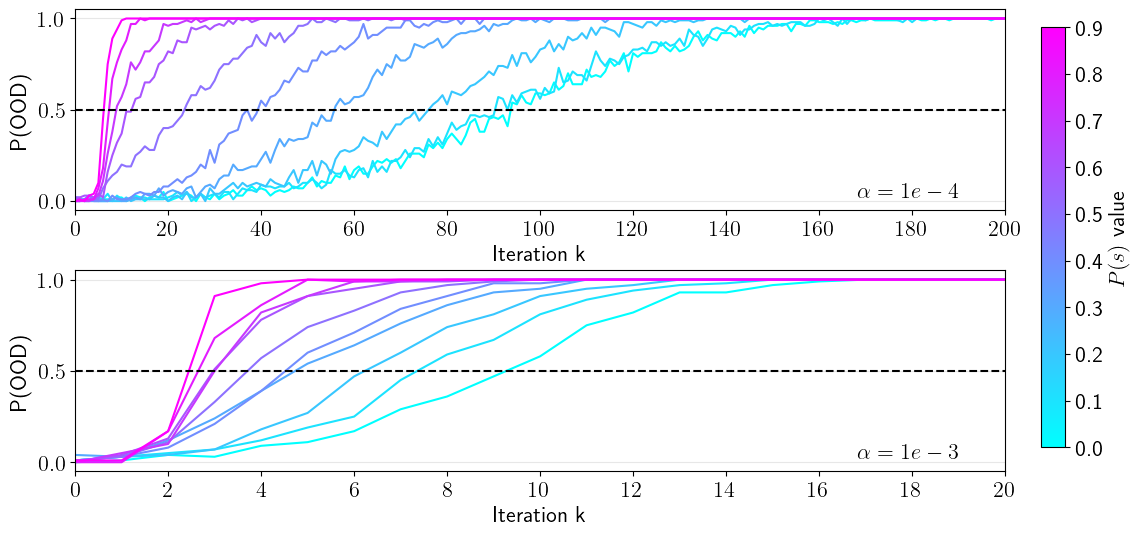

In [67]:
fig, axes = plt.subplots(len(alphas), 1, figsize=(12, 6))
norm = mcolors.Normalize(vmin=min(ps), vmax=max(ps))
cmap = cm.get_cmap('cool')

for i, (alpha, k_max, name) in enumerate(zip(alphas, [200, 20], ["1e-4", "1e-3"])):
    for p in ps:
        color = cmap(norm(p))
        ood_prob, _ = simulate_noise(alpha, p, d, k_max)
        axes[i].plot(ood_prob, color=color)

    axes[i].set_xlabel('Iteration k')
    axes[i].set_ylabel('P(OOD)')
    axes[i].grid(axis="y", alpha=0.3)
    axes[i].axhline(y=0.5, color="black", linestyle="--")

    axes[i].set_xlim([0, k_max])
    axes[i].xaxis.set_major_locator(AutoLocator())

    axes[i].text(
        x=0.95 * k_max,
        y=0.1 * axes[i].get_ylim()[1],
        s=fr'$\alpha={name}$',
        ha='right', va='top',
        fontsize=16,
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none')
    )
    axes[i].set_xticks([x for x in np.arange(0,k_max+1, k_max//10) if x <= k_max])

# cbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('$P(s)$ value')
cbar.set_ticks(ps)
cbar.set_ticklabels([f'{p:.1f}' for p in ps])

plt.subplots_adjust(hspace=0.3, right=0.9)
plt.savefig("figures/Appx.pdf", bbox_inches="tight", dpi=200)

/tmp/ipykernel_3466325/401903462.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool')


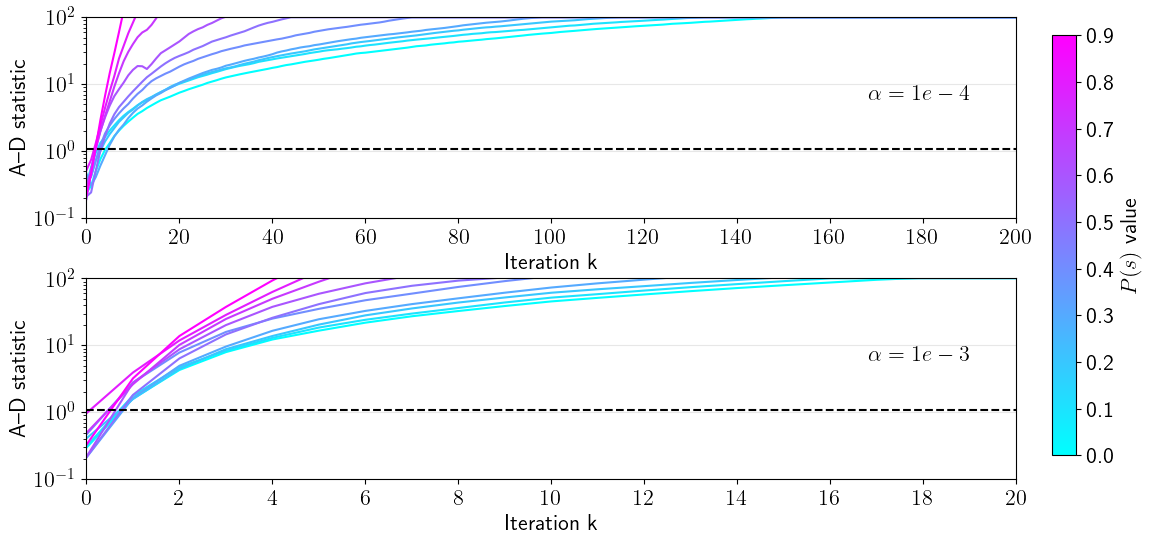

In [14]:
fig, axes = plt.subplots(len(alphas), 1, figsize=(12, 6))
norm = mcolors.Normalize(vmin=min(ps), vmax=max(ps))
cmap = cm.get_cmap('cool')

for i, (alpha, k_max, name) in enumerate(zip(alphas, [200, 20], ["1e-4", "1e-3"])):
    for p in ps:
        color = cmap(norm(p))
        _, zs_full = simulate_noise(alpha=alpha, p=p, d=d, k_max=k_max)

        ad_vals = np.zeros(k_max+1)
        for k in range(k_max+1):
            a_samples = zs_full[k].ravel()
            a_stat = anderson(a_samples, dist='norm')
            ad_vals[k] = a_stat.statistic
            if ad_vals[k] > 100:  # Do not compute massive Statistics for runtime
                ad_vals[k+1:] = ad_vals[k]
                break
        axes[i].plot(ad_vals, color=color)

    axes[i].set_xlabel('Iteration k')
    axes[i].set_ylabel('A–D statistic')
    axes[i].grid(axis="y", alpha=0.3)

    axes[i].set_xlim([0, k_max])
    axes[i].xaxis.set_major_locator(AutoLocator())
    axes[i].set_ylim([1e-1, 100])
    axes[i].set_yscale("log")
    axes[i].axhline(y=a_stat.critical_values[-1], color="black", linestyle="--")

    axes[i].text(
        x=0.95 * k_max,
        y=0.1 * axes[i].get_ylim()[1],
        s=fr'$\alpha={name}$',
        ha='right', va='top',
        fontsize=16,
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none')
    )
    axes[i].set_xticks([x for x in np.arange(0, k_max+1, k_max//10) if x <= k_max])

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('$P(s)$ value')
cbar.set_ticks(ps)
cbar.set_ticklabels([f'{p:.1f}' for p in ps])

plt.subplots_adjust(hspace=0.3, right=0.9)
plt.savefig("figures/AD_stats.pdf", bbox_inches="tight", dpi=200)
plt.show()